In [1]:
import pathlib
import numpy as np
import pandas as pd

import Bio
import Bio.Seq
import Bio.SeqIO

import pysam

from scipy.stats import poisson

import matplotlib.pyplot as plt
import seaborn as sns

## Get CCS Read data and create summary statistics

In [2]:
data_dir = pathlib.Path("../data/scratch/Oct22")
figs_dir = pathlib.Path("../data/misc")

In [3]:
samples = pd.read_csv(data_dir / "Samples.csv")
samples[["parent", "category"]] = samples["sample"].str.split("_", expand=True)
samples["frac_kept"] = samples.num_kept / samples.num_seqs
samples.set_index("barcode", inplace=True)
samples

,sample,num_placed,num_seqs,num_kept,align_filter,length_filter,quality_filter,parent,category,frac_kept
barcode,,,,,,,,,,
bcAd1036T,1VH_H,4,127801,75214,101908,99932,75214,1VH,H,0.588524
bcAd1037T,1VH_P,2,91298,29062,41772,38552,29062,1VH,P,0.318320
bcAd1039T,1VH_L,349,159287,77991,109574,105660,77991,1VH,L,0.489626
bcAd1040T,1VH_N,454,117798,40370,62755,54346,40370,1VH,N,0.342705
bcAd1043T,2L_H,29,89971,42280,64424,59930,42280,2L,H,0.469929
bcAd1044T,2L_P,52,33222,14146,22144,20246,14146,2L,P,0.425802
bcAd1045T,2L_L,532,170155,67602,98802,94426,67602,2L,L,0.397297
bcAd1046T,2L_N,287,143675,43242,62543,60169,43242,2L,N,0.300971
bcAd1047T,3VRL_H,81,87753,47470,68389,63481,47470,3VRL,H,0.540950


In [4]:
samples_melt = pd.melt(samples, id_vars=["parent", "category"], 
        value_vars=["num_seqs", "align_filter", "length_filter", "quality_filter"])

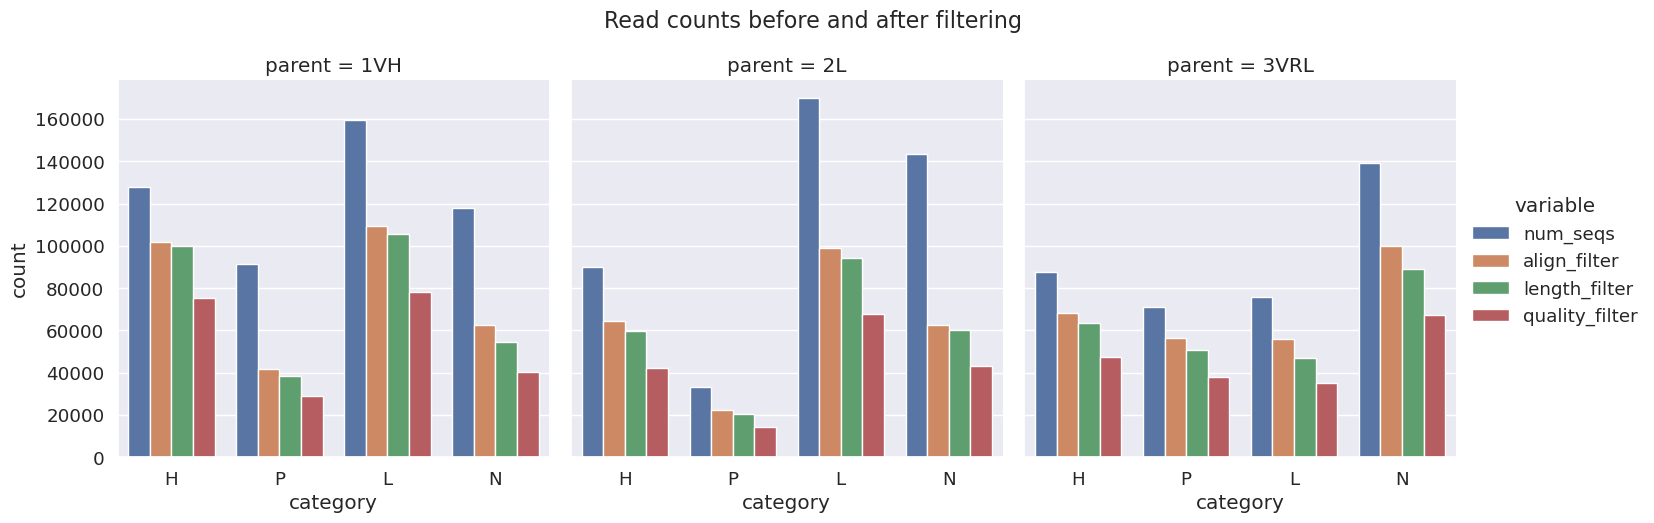

In [5]:
sns.set(font_scale=1.2)

g = sns.catplot(data=samples_melt, x="category", y="value", hue="variable",
            col="parent", kind="bar")

g.fig.suptitle("Read counts before and after filtering", size=16, y=1.05)
g.axes[0,0].set_ylabel("count")
plt.savefig(figs_dir / "Raw Read Counts.png", dpi=300)

pass

## Count unique CCS sequences and locate parents

In [6]:
# read in all the filtered sequences
value_counts_d = {}
for filename in data_dir.glob("*.tsv"):
    x = pd.read_csv(filename, sep="\t")
    y = x.groupby("ss_dna").agg(
     dna_count = ('ss_dna', len),
     dna_dist = ('dna_dist', lambda x: x.head(1)),
     aa_dist = ('aa_dist', lambda x: x.head(1)),    
     #ref_dist = ('ref_dist', lambda x: x.head(1)), # ref_dist is dna_dist
     ss_aa = ('ss_aa', lambda x: x.head(1)),    
    ).sort_values(by='dna_count', ascending=False).reset_index()
    y['early_stop'] = y.ss_aa.str.contains("\*") & (y.ss_aa != "*0*")
    value_counts_d[filename.stem] = y

In [7]:
def add_parent_and_category(barcode, vcs):
    x = vcs
    x["seq_rank"] = x.index + 1
    x["parent"] = samples.loc[barcode].parent
    x["category"] = samples.loc[barcode].category
    return x

In [8]:
all_seqs = pd.concat([add_parent_and_category(barcode, vcs) for barcode, vcs
                       in value_counts_d.items()])
all_seqs["parent"] = pd.Categorical(all_seqs.parent, categories=["1VH", "2L", "3VRL"],
                                    ordered=True)
all_seqs["category"] = pd.Categorical(all_seqs.category, categories=["H", "P", "L", "N"],
                                     ordered=True)
all_seqs

,ss_dna,dna_count,dna_dist,aa_dist,ss_aa,early_stop,seq_rank,parent,category
0,*0*,6378,0,0,*0*,False,1,2L,H
1,"A21G,G55A,A663G,A675G",2072,4,1,E19K,False,2,2L,H
2,A295G,1955,1,1,I99V,False,3,2L,H
3,"A75G,A191G,A386G,T423G,G687A",1949,5,3,"K64R,H129R,M229I",False,4,2L,H
4,"T391C,A612G",1866,2,1,Y131H,False,5,2L,H
...,...,...,...,...,...,...,...,...,...
53,"G43T,C241A,T454C,T594A",1,4,4,"A15S,L81M,F152L,N198K",False,54,1VH,H
54,"G43T,G46C,T454C,T594A",1,4,4,"A15S,A16P,F152L,N198K",False,55,1VH,H
55,"G43T,T215G,T454C,T594A",1,4,4,"A15S,V72G,F152L,N198K",False,56,1VH,H
56,"G43T,T308C,T454C",1,3,3,"A15S,V103A,F152L",False,57,1VH,H


In [9]:
# look at the top 3 sequences in each bin
top_3_seqs = all_seqs.groupby(["parent", "category"]).head(3)
cols_at_end = ["ss_dna", "ss_aa"]
df = top_3_seqs.sort_values(by=["parent", "category"])
(df[[l for l in list(df.columns) if l not in cols_at_end] + cols_at_end]
 .set_index(["parent", "category"])
)

dna_count  dna_dist  aa_dist  early_stop  seq_rank  \
parent category                                                       
1VH    H             20356         3        3       False         1   
       H             18573         1        1       False         2   
       H             17532         3        3       False         3   
       P             29019         2        2       False         1   
       P                 6         3        3       False         2   
       P                 2         3        3       False         3   
       L              3876         0        0       False         1   
       L              1200         2        2       False         2   
       L               598         1        1       False         3   
       N              2219         4        4       False         1   
       N               634         7        5       False         2   
       N               494         5        3       False         3   
2L     H              6378         0        0       False         1   
       H              2072         4        1       False         2   
       H              1955         1        1       False         3   
       P              1365         0        0       False         1   
       P               775         1        0       False         2   
       P               425         3        0       False         3   
       L              1497         0        0       False         1   
       L               395         9        4       False         2   
       L               336         5        2       False         3   
       N               650         0        0       False         1   
       N               607         9        7       False         2   
       N               600         4        3       False         3   
3VRL   H             13664         2        0       False         1   
       H              1045        11        8       False         2   
       H              1024         3        0       False         3   
       P              2670         2        0       False         1   
       P               515         5        1       False         2   
       P               432         3        1       False         3   
       L               759         2        0       False         1   
       L               498         4        1       False         2   
       L               491         3        0       False         3   
       N               932         3        0       False         1   
       N               892         7        3       False         2   
       N               755         4        1       False         3   

                                                            ss_dna  \
parent category                                                      
1VH    H                                          G43T,T454C,T594A   
       H                                                     A679G   
       H                                          C17G,A178G,G257A   
       P                                                C71T,A565G   
       P                                          C71T,A565G,A791G   
       P                                          C71T,A565G,C790T   
       L                                                       *0*   
       L                                               A328T,G774T   
       L                                                     A107T   
       N                                    G91A,C104G,G422A,A577T   
       N                  A48G,G462A,A512G,A554G,G585A,C595T,T718C   
       N                             T542C,A663G,C695T,A714G,G776A   
2L     H                                                       *0*   
       H                                     A21G,G55A,A663G,A675G   
       H                                                     A295G   
       P                                                       *0*   
       P                                                  

In [10]:
# number of samples placed in each bin by Christian
samples_placed_df = samples[["parent", "category", "num_placed"]].copy()
samples_placed_df

,parent,category,num_placed
barcode,,,
bcAd1036T,1VH,H,4
bcAd1037T,1VH,P,2
bcAd1039T,1VH,L,349
bcAd1040T,1VH,N,454
bcAd1043T,2L,H,29
bcAd1044T,2L,P,52
bcAd1045T,2L,L,532
bcAd1046T,2L,N,287
bcAd1047T,3VRL,H,81


In [11]:
# find the colors for H,P,L,N
pal = sns.color_palette()
color_d = {x:y for  x, y in zip("HPLN", pal)}
pal

[(0.2980392156862745, 0.4470588235294118, 0.6901960784313725),
 (0.8666666666666667, 0.5176470588235295, 0.3215686274509804),
 (0.3333333333333333, 0.6588235294117647, 0.40784313725490196),
 (0.7686274509803922, 0.3058823529411765, 0.3215686274509804),
 (0.5058823529411764, 0.4470588235294118, 0.7019607843137254),
 (0.5764705882352941, 0.47058823529411764, 0.3764705882352941),
 (0.8549019607843137, 0.5450980392156862, 0.7647058823529411),
 (0.5490196078431373, 0.5490196078431373, 0.5490196078431373),
 (0.8, 0.7254901960784313, 0.4549019607843137),
 (0.39215686274509803, 0.7098039215686275, 0.803921568627451)]

In [12]:
# find locations of parent dna sequences
parent_locations_df = all_seqs[all_seqs["ss_dna"] == "*0*"]
parent_locations_df

,ss_dna,dna_count,dna_dist,aa_dist,ss_aa,early_stop,seq_rank,parent,category
0,*0*,6378,0,0,*0*,False,1,2L,H
0,*0*,1497,0,0,*0*,False,1,2L,L
0,*0*,1365,0,0,*0*,False,1,2L,P
0,*0*,650,0,0,*0*,False,1,2L,N
0,*0*,3876,0,0,*0*,False,1,1VH,L
4,*0*,389,0,0,*0*,False,5,1VH,N
3,*0*,11321,0,0,*0*,False,4,1VH,H


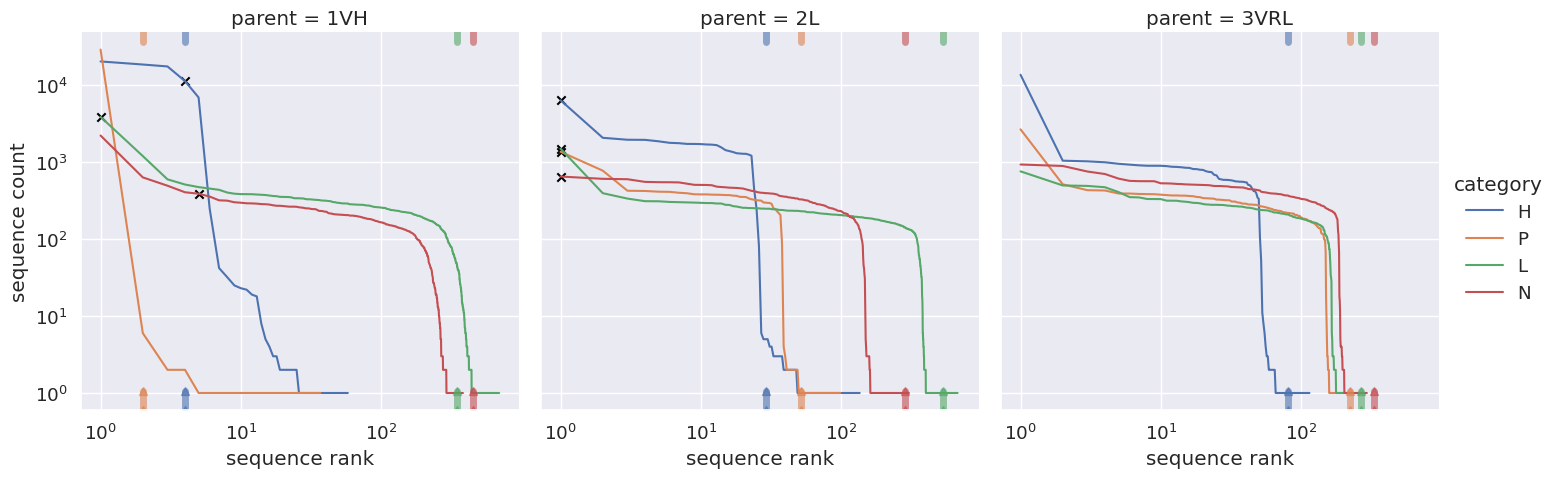

In [13]:
g = sns.relplot(data=all_seqs, x="seq_rank", y="dna_count", 
                col="parent", hue="category", kind="line")
g.set(xscale="log", yscale="log", 
       xlabel="sequence rank", ylabel="sequence count")

for parent, ax in g.axes_dict.items():
    samples_parent = samples_placed_df[samples_placed_df.parent == parent]
    for idx, row in samples_parent.iterrows():
        category = row.category
        #print(row.category, row.samples_placed)
        parent_locs = parent_locations_df[
                        (parent_locations_df.parent == parent) & 
                        (parent_locations_df.category == category)]
        if len(parent_locs):
            ax.scatter(parent_locs["seq_rank"], parent_locs["dna_count"],
                       marker="x", color="black")
        ax.axvline(row.num_placed, ymax=0.05, lw=5, alpha=0.6, marker="^", 
                   color=color_d[category])
        ax.axvline(row.num_placed, ymin=0.975, lw=5, alpha=0.6,  
                   color=color_d[category])        
g.savefig(figs_dir / "dna_sequences_recovered.png", dpi=300)
pass

In [14]:
# where we should place the horizontal cutoffs (dna_count)
# we do this by eyeballing the graph above to look for the steep dropoffs

# set them all to 100 first
samples_placed_df[["dna_cutoff"]] = 100

# set the ones that should be above 100
samples_placed_df.loc[
    (samples_placed_df.parent == "1VH") & 
    (samples_placed_df.category == "H"), "dna_cutoff"] = 10000
samples_placed_df.loc[
    (samples_placed_df.parent == "1VH") & 
    (samples_placed_df.category == "P"), "dna_cutoff"] = 10000

samples_placed_df.loc[
    (samples_placed_df.parent == "2L") & 
    (samples_placed_df.category == "H"), "dna_cutoff"] = 1000

In [15]:
# Look for parent amino acid sequences but sorted by dna counts
(all_seqs[all_seqs["ss_aa"] == "*0*"]
 .groupby(["parent", "category"])
 .head(3)
 .sort_values(by=["parent", "category"])
 .set_index(["parent", "category"])
)

ss_dna  dna_count  dna_dist  aa_dist  \
parent category                                                               
1VH    H                                  *0*      11321         0        0   
       H                                T558A          1         1        0   
       L                                  *0*       3876         0        0   
       L                                A432G        384         1        0   
       L                                T558C        368         1        0   
       N                                  *0*        389         0        0   
       N                          A285G,G375A        198         2        0   
       N                           A21G,T351C        141         2        0   
2L     H                                  *0*       6378         0        0   
       H                                T423C       1724         1        0   
       H              A219G,A441G,T456C,T783C       1716         4        0   
       P                                  *0*       1365         0        0   
       P                                 A75G        775         1        0   
       P                    T258C,T426C,G735C        425         3        0   
       L                                  *0*       1497         0        0   
       L                          A105G,A714G        311         2        0   
       L                                A207G        255         1        0   
       N                                  *0*        650         0        0   
       N                                A633G        276         1        0   
       N                          T135C,T318A          3         2        0   
3VRL   H                           T33C,C699G      13664         2        0   
       H                     T33C,T609C,C699G       1024         3        0   
       H         T33C,A264G,A444G,T528G,C699G        952         5        0   
       P                           T33C,C699G       2670         2        0   
       P                     T33C,C357A,C699G        391         3        0   
       P         T33C,T144A,C342T,A654G,C699G        369         5        0   
       L                           T33C,C699G        759         2        0   
       L                     T33C,C699G,T783A        491         3        0   
       L                     T33C,C699G,A729G        256         3        0   
       N                     T33C,C699G,C795A        932         3        0   
       N                     T33C,T138C,C699G        486         3        0   
       N                     T33C,A402G,C699G        446         3        0   

                ss_aa  early_stop  seq_rank  
parent category                              
1VH    H          *0*       False         4  
       H          *0*       False        39  
       L          *0*       False         1  
       L          *0*       False        11  
       L          *0*       False        16  
       N          *0*       False         5  
       N          *0*       False        68  
       N          *0*       False       134  
2L     H          *0*       False         1  
       H          *0*       False         9  
       H          *0*       False        10  
       P          *0*       False         1  
       P          *0*       False         2  
       P          *0*       False         3  
       L          *0*       False         1  
       L          *0*       False         4  
       L          *0*       False        21  
       N          *0*       False         1  
       N          *0*       False        74  
       N          *0*       False       152  
3VRL   H          *0*       False         1  
       H          *0*       False         3  
       H          *0*       False         5  
       P          *0*       False         1  
       P          *0*       False         5  
       P          *0*       False        12  
       L          *0*       False         1  
       L          

## Filter CCS sequences
* Keep only the top n seqs in each bin where n = number of sequences placed in each bin
* Keep sequences where the dna_count is above the steep dropoff in the graph above
* Keep sequences with dna_distance < 12
* Keep sequences that do not have an early termination codon when translated

Save the sequences that are left to a tsv file

In [16]:
def get_num_samples_placed(parent, category):
    return samples_placed_df.num_placed[
        (samples_placed_df["parent"] == parent) &
        (samples_placed_df["category"] == category)].item()

placed_cutoff_seqs = pd.concat(
            g.head(get_num_samples_placed(parent, category)) 
            for (parent, category), g in all_seqs.groupby(["parent", "category"])
)
placed_cutoff_seqs

,ss_dna,dna_count,dna_dist,aa_dist,ss_aa,early_stop,seq_rank,parent,category
0,"G43T,T454C,T594A",20356,3,3,"A15S,F152L,N198K",False,1,1VH,H
1,A679G,18573,1,1,K227E,False,2,1VH,H
2,"C17G,A178G,G257A",17532,3,3,"P6R,S60G,G86D",False,3,1VH,H
3,*0*,11321,0,0,*0*,False,4,1VH,H
0,"C71T,A565G",29019,2,2,"A24V,N189D",False,1,1VH,P
...,...,...,...,...,...,...,...,...,...
290,"T33C,A623T,T626A,C699G,C795A",1,5,2,"E208V,M209K",False,291,3VRL,N
291,"T33C,A623T,T626A,C699G,A731G",1,5,3,"E208V,M209K,N244S",False,292,3VRL,N
292,"T33C,A57G,A124T,T151A,T308A,A629G,C699G",1,7,4,"I42F,W51R,V103D,H210R",False,293,3VRL,N
293,"T33C,A563G,C699G,C740A",1,4,2,"D188G,A247D",False,294,3VRL,N


In [17]:
def get_dna_cutoff(parent, category):
    return samples_placed_df.dna_cutoff[
        (samples_placed_df["parent"] == parent) &
        (samples_placed_df["category"] == category)].item()

dna_cutoff_seqs = pd.concat(
            g[g.dna_count >= get_dna_cutoff(parent, category)]
            for (parent, category), g in placed_cutoff_seqs.groupby(["parent", "category"])
)
dna_cutoff_seqs

,ss_dna,dna_count,dna_dist,aa_dist,ss_aa,early_stop,seq_rank,parent,category
0,"G43T,T454C,T594A",20356,3,3,"A15S,F152L,N198K",False,1,1VH,H
1,A679G,18573,1,1,K227E,False,2,1VH,H
2,"C17G,A178G,G257A",17532,3,3,"P6R,S60G,G86D",False,3,1VH,H
3,*0*,11321,0,0,*0*,False,4,1VH,H
0,"C71T,A565G",29019,2,2,"A24V,N189D",False,1,1VH,P
...,...,...,...,...,...,...,...,...,...
180,"T33C,G382T,C699G",185,3,1,G128C,False,181,3VRL,N
181,"T33C,A200T,A444G,T551C,C699G",180,5,2,"H67L,I184T",False,182,3VRL,N
182,"T33C,A78G,C458T,A663T,C699G,C706T",148,6,2,"A153V,Q236*",True,183,3VRL,N
183,"T33C,T656C,C699G,C713T",125,4,2,"I219T,T238I",False,184,3VRL,N


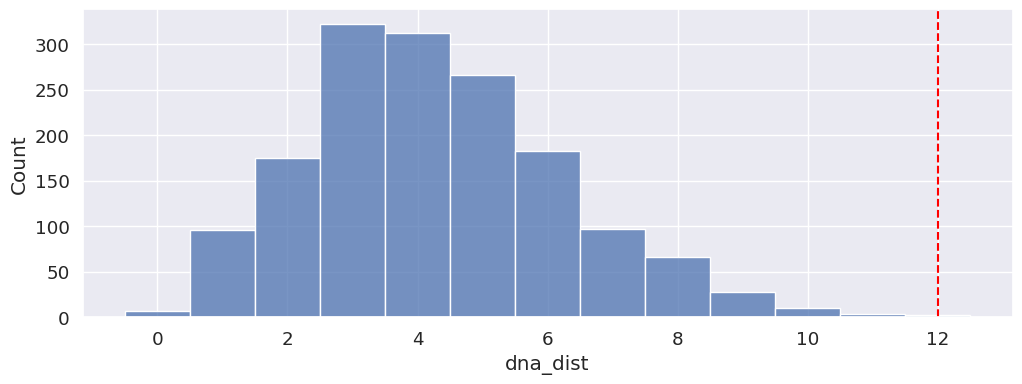

In [18]:
dna_distance_cutoff = 12

fig, ax = plt.subplots(figsize=(12, 4))
sns.histplot(dna_cutoff_seqs.dna_dist, discrete=True, ax=ax)
ax.axvline(dna_distance_cutoff, color="red", linestyle="--")
pass

In [19]:
dist_cutoff_seqs = dna_cutoff_seqs[dna_cutoff_seqs.dna_dist < dna_distance_cutoff]
dist_cutoff_seqs

,ss_dna,dna_count,dna_dist,aa_dist,ss_aa,early_stop,seq_rank,parent,category
0,"G43T,T454C,T594A",20356,3,3,"A15S,F152L,N198K",False,1,1VH,H
1,A679G,18573,1,1,K227E,False,2,1VH,H
2,"C17G,A178G,G257A",17532,3,3,"P6R,S60G,G86D",False,3,1VH,H
3,*0*,11321,0,0,*0*,False,4,1VH,H
0,"C71T,A565G",29019,2,2,"A24V,N189D",False,1,1VH,P
...,...,...,...,...,...,...,...,...,...
180,"T33C,G382T,C699G",185,3,1,G128C,False,181,3VRL,N
181,"T33C,A200T,A444G,T551C,C699G",180,5,2,"H67L,I184T",False,182,3VRL,N
182,"T33C,A78G,C458T,A663T,C699G,C706T",148,6,2,"A153V,Q236*",True,183,3VRL,N
183,"T33C,T656C,C699G,C713T",125,4,2,"I219T,T238I",False,184,3VRL,N


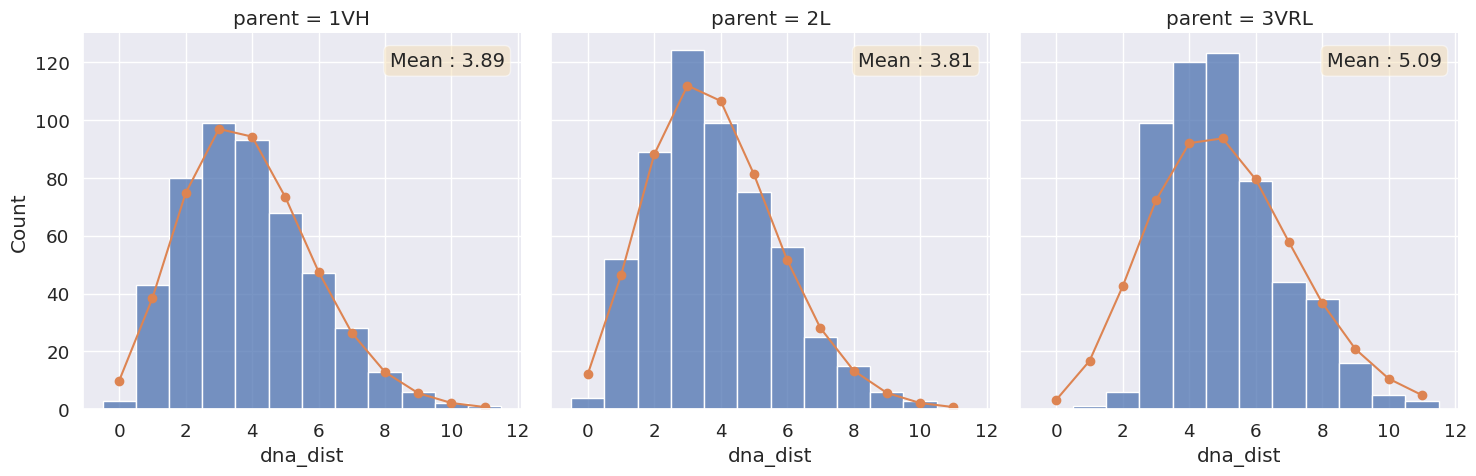

In [20]:
g = sns.displot(data=dist_cutoff_seqs,
                x="dna_dist", col="parent", discrete=True)

for parent, ax in g.axes_dict.items():
    mask = (dist_cutoff_seqs["parent"] == parent)
    dna_dists = dist_cutoff_seqs["dna_dist"][mask]
    N = len(dna_dists)
    p_mean = dna_dists.mean()
    x_vals = np.arange(0, int(ax.get_xlim()[1]))
    poisson_estimates = poisson.pmf(x_vals, p_mean) * N
    ax.plot(x_vals, poisson_estimates, "o-", color=sns.color_palette()[1])
    
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    textstr = f"Mean : {p_mean:.2f}"
    ax.text(0.70, 0.95, textstr, transform=ax.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
pass

In [21]:
def extract_mutation_positions(s):
    """Takes a string of mutants  and returns the positions
        that were mutated. e.g. s=C71T,A565G ret=[71, 565]
        Special handling "*0*" return None
    """
    ret = None
    if s != "*0*":
        ret = [int(m[1:-1]) for m in s.split(",")]
    return ret

ret = extract_mutation_positions("*0*")
assert(ret is None)
ret = extract_mutation_positions("C71T,A565G")
assert(ret == [71, 565])

In [22]:
def make_mut_postions_into_df(row):
    positions = extract_mutation_positions(row.ss_dna)
    ret = None
    if positions is not None:
        ret = pd.DataFrame(positions)
        ret.columns=["mut_positions"]
        ret["parent"] = row.parent
        ret["category"] = row.category
        ret["seq_rank"] = row.seq_rank
    return ret

#mut_positions_df = [make_mut_postions_into_df(row) 
#               in dist_cutoff_seqs.itertuples(index=False)]

all_mut_positions = []
for row in dist_cutoff_seqs.itertuples(index=False):
    x = make_mut_postions_into_df(row)
    all_mut_positions.append(x)

all_mut_positions_df = pd.concat(all_mut_positions)
all_mut_positions_df.head()

,mut_positions,parent,category,seq_rank
0,43,1VH,H,1
1,454,1VH,H,1
2,594,1VH,H,1
0,679,1VH,H,2
0,17,1VH,H,3


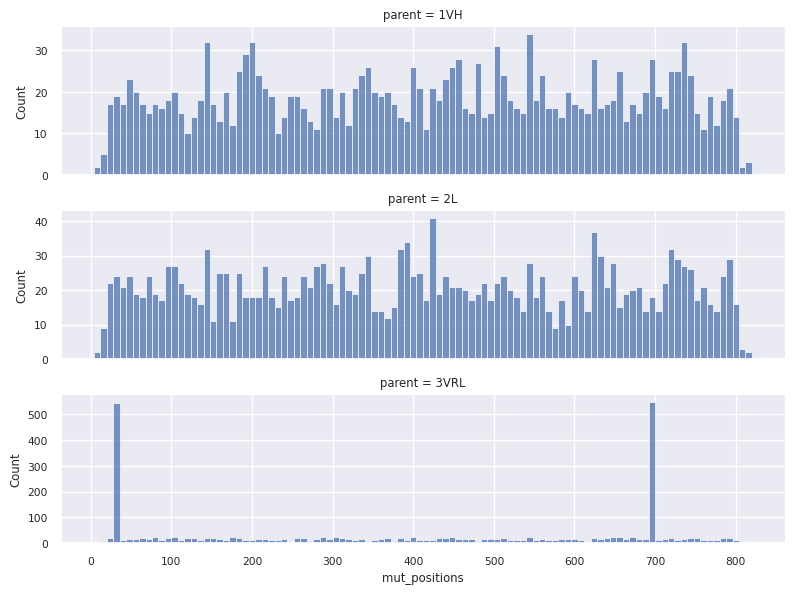

In [23]:
sns.set(font_scale=0.7)
sns.displot(data=all_mut_positions_df, x="mut_positions", row="parent", 
            height=2, aspect=4, facet_kws=dict(sharey=False), binwidth=8)

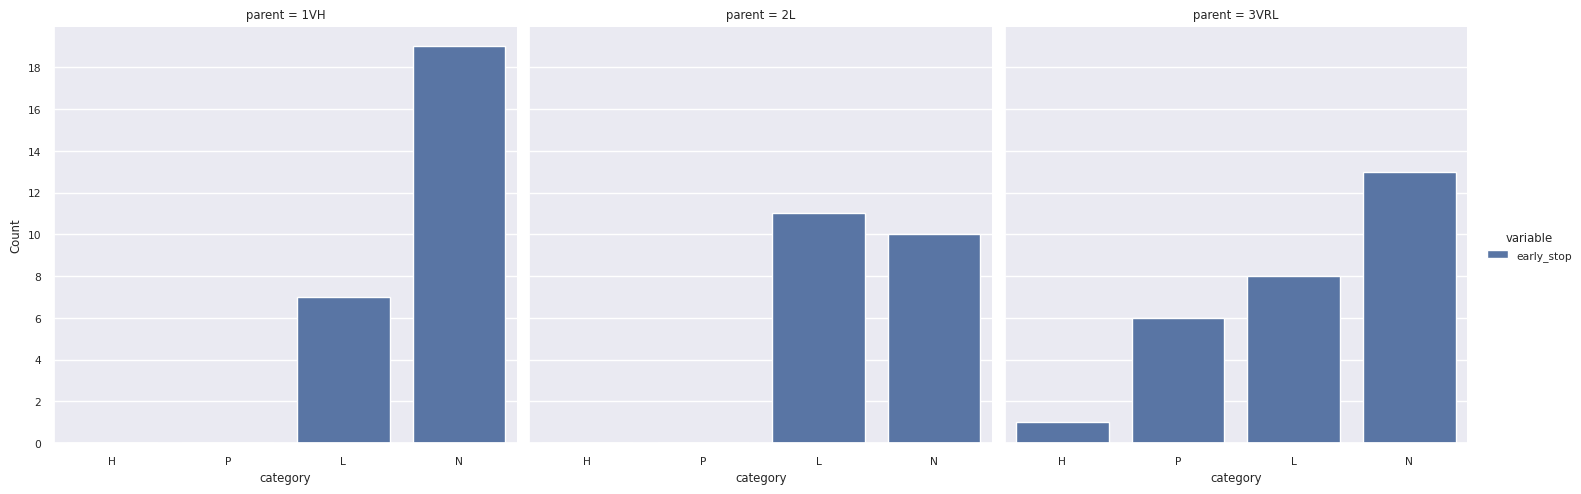

In [24]:
early_stop_counts_df = dist_cutoff_seqs.groupby(["parent", "category"])["early_stop"].agg(sum)

g = sns.catplot(data=pd.melt(early_stop_counts_df.reset_index(), ["parent", "category"]), 
                x="category", y="value", hue="variable",
            col="parent", kind="bar")

from matplotlib.ticker import MaxNLocator
ax = g.axes[0, 0]
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_ylabel("Count")
pass

In [25]:
no_truncated_seqs = dist_cutoff_seqs[~dist_cutoff_seqs.early_stop]
no_truncated_seqs

,ss_dna,dna_count,dna_dist,aa_dist,ss_aa,early_stop,seq_rank,parent,category
0,"G43T,T454C,T594A",20356,3,3,"A15S,F152L,N198K",False,1,1VH,H
1,A679G,18573,1,1,K227E,False,2,1VH,H
2,"C17G,A178G,G257A",17532,3,3,"P6R,S60G,G86D",False,3,1VH,H
3,*0*,11321,0,0,*0*,False,4,1VH,H
0,"C71T,A565G",29019,2,2,"A24V,N189D",False,1,1VH,P
...,...,...,...,...,...,...,...,...,...
179,"T33C,A263T,A491T,G690A,C699G",187,5,2,"K88I,D164V",False,180,3VRL,N
180,"T33C,G382T,C699G",185,3,1,G128C,False,181,3VRL,N
181,"T33C,A200T,A444G,T551C,C699G",180,5,2,"H67L,I184T",False,182,3VRL,N
183,"T33C,T656C,C699G,C713T",125,4,2,"I219T,T238I",False,184,3VRL,N


In [26]:
no_truncated_seqs.to_csv("../data/sequences_Oct22.tsv", sep="\t", index=False)

In [27]:
# with pd.option_context('display.max_rows', None):
#     display(no_truncated_seqs.drop("early_stop", axis="columns"))

In [28]:
final_filtered_seqs = no_truncated_seqs

In [29]:
samples_placed_recovered_df = pd.merge(
     samples_placed_df.drop(columns="dna_cutoff") ,
    final_filtered_seqs.groupby(["parent", "category"]).agg(     
        samples_recovered = ('ss_dna', len),
        ).reset_index())

samples_placed_recovered_df.set_index(["parent", "category"])

num_placed  samples_recovered
parent category                               
1VH    H                  4                  4
       P                  2                  1
       L                349                291
       N                454                161
2L     H                 29                 23
       P                 52                 37
       L                532                337
       N                287                130
3VRL   H                 81                 50
       P                222                139
       L                266                146
       N                330                171

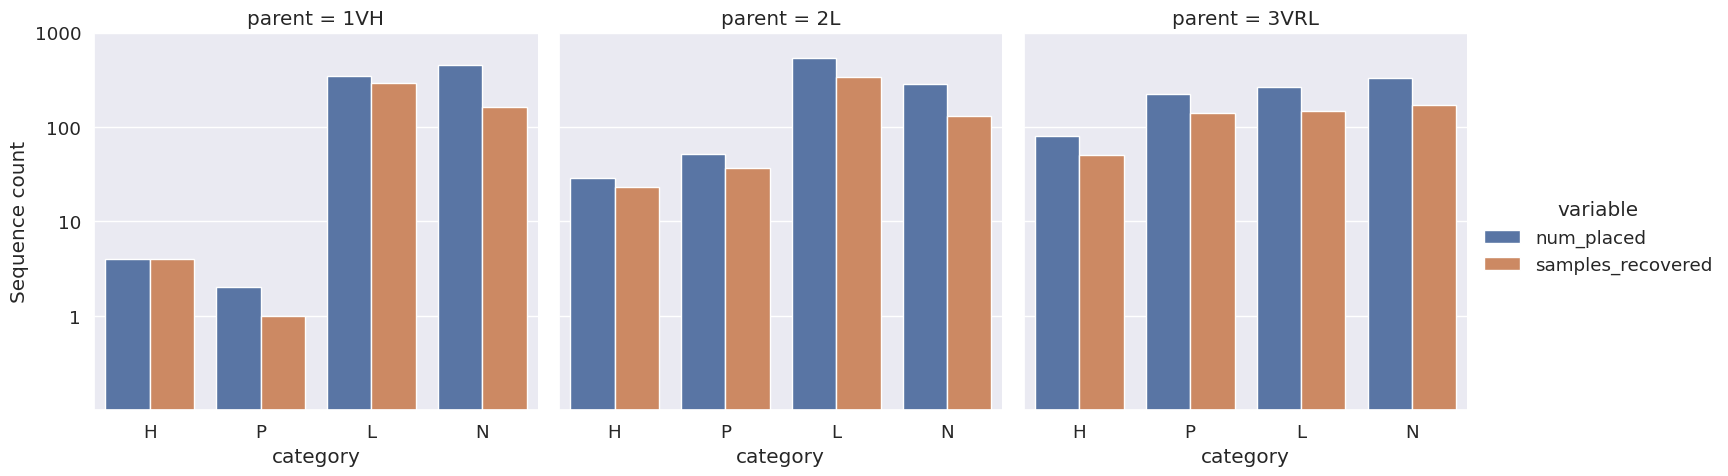

In [30]:
sns.set(font_scale=1.2)

g = sns.catplot(data=pd.melt(samples_placed_recovered_df, ["parent", "category"]), 
                x="category", y="value", hue="variable",
            col="parent", kind="bar")

ticks = [0.1, 1, 10, 100, 1000]
ticklabels = list(map(str, ticks))
ticklabels[0] = " "
g.set(yscale="log", yticks=ticks, yticklabels=ticklabels)
g.axes[0, 0].set_ylabel("Sequence count")
pass